In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("28-urban_pedestrian_locations_with_labels.csv")

In [7]:
data

,x_position,y_position,true_cluster
0,0.830586,-0.447733,1
1,0.701678,0.816918,0
2,1.022080,-0.492571,1
3,-0.316765,0.953438,0
4,0.293226,1.057185,0
...,...,...,...
495,0.239754,0.985462,0
496,0.072145,0.184834,1
497,0.590273,-0.365577,1
498,1.619465,-0.283658,1


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   x_position    500 non-null    float64
 1   y_position    500 non-null    float64
 2   true_cluster  500 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 11.8 KB


In [5]:
data.isnull().sum()

x_position      0
y_position      0
true_cluster    0
dtype: int64

In [6]:
data.describe()

,x_position,y_position,true_cluster
count,500.000000,500.000000,500.000000
mean,0.504536,0.251342,0.500000
std,0.870047,0.498529,0.500501
min,-1.079039,-0.605083,0.000000
25%,-0.030705,-0.223623,0.000000
50%,0.484762,0.265299,0.500000
75%,1.039928,0.699438,1.000000
max,2.083614,1.111774,1.000000


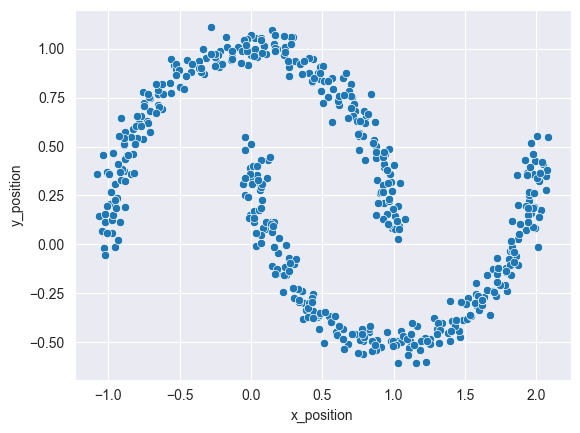

In [8]:
sns.scatterplot(data=data, x="x_position", y="y_position")
plt.show()

In [9]:
data = data.drop("true_cluster", axis=1)

In [10]:
data.head()

,x_position,y_position
0,0.830586,-0.447733
1,0.701678,0.816918
2,1.022080,-0.492571
3,-0.316765,0.953438
4,0.293226,1.057185


In [12]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data)

In [13]:
from sklearn.cluster import DBSCAN

In [16]:
# https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html

dbscan = DBSCAN()

In [17]:
dbscan.fit(X_scaled)

,eps,0.5
,min_samples,5
,metric,'euclidean'
,metric_params,None
,algorithm,'auto'
,leaf_size,30
,p,None
,n_jobs,None


In [18]:
dbscan.labels_

array([0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1,
       1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1,
       0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1,
       0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1,
       0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1,
       1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1,
       1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,

In [19]:
X_scaled = pd.DataFrame(X_scaled, columns=["x_position", "y_position"])

In [20]:
X_scaled

,x_position,y_position
0,0.375125,-1.403679
1,0.226815,1.135628
2,0.595442,-1.493710
3,-0.944918,1.409748
4,-0.243115,1.618062
...,...,...
495,-0.304636,1.474047
496,-0.497472,-0.133542
497,0.098642,-1.238718
498,1.282741,-1.074231


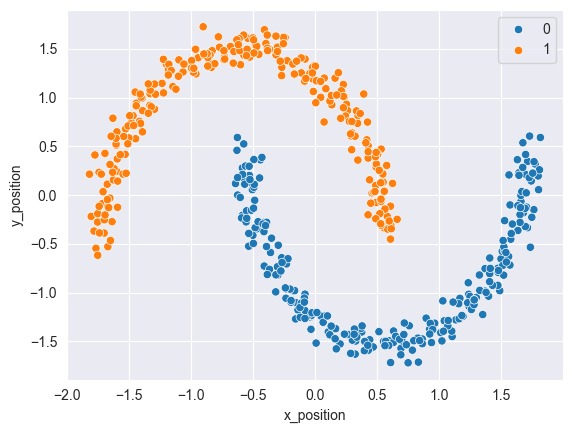

In [22]:
sns.scatterplot(data=X_scaled, x="x_position", y="y_position", hue=dbscan.labels_)
plt.show()

In [27]:
#after dbscan check true cluster columns value category
data = pd.read_csv("28-urban_pedestrian_locations_with_labels.csv")

In [24]:
data.columns

Index(['x_position', 'y_position', 'true_cluster'], dtype='object')

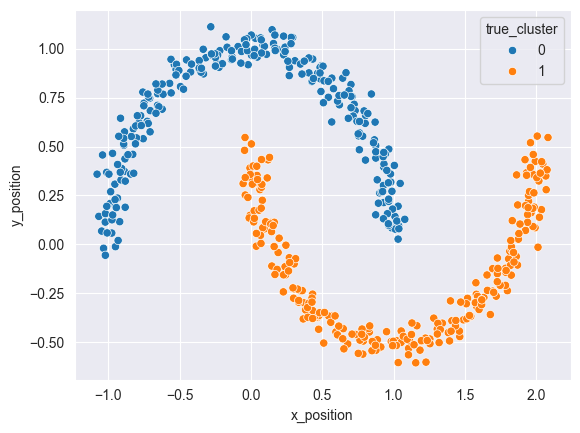

In [25]:
sns.scatterplot(data=data, x="x_position", y="y_position", hue="true_cluster")
plt.show()

In [28]:
#hyperparameter tuning

In [29]:
eps_values = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6]
min_samples_values = [4, 5, 6]

In [30]:
from sklearn.metrics import silhouette_score

In [32]:
results = []

for eps in eps_values:
    for min_samples in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=min_samples).fit(X_scaled)
        labels = db.labels_

        if len(set(labels)) <= 1:
            continue
        silhouette_scores = silhouette_score(X_scaled, labels)
        results.append(
            {
                "eps": eps,
                "min_samples": min_samples,
                "silhouette_score": silhouette_scores,
                "n_clusters": len(set(labels)) - (1 if -1 in labels else 0),
            }
        )
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="silhouette_score", ascending=False)

In [34]:
results_df

,eps,min_samples,silhouette_score,n_clusters
4,0.2,5,0.389338,2
3,0.2,4,0.389338,2
14,0.5,6,0.389338,2
11,0.4,6,0.389338,2
5,0.2,6,0.389338,2
6,0.3,4,0.389338,2
8,0.3,6,0.389338,2
7,0.3,5,0.389338,2
9,0.4,4,0.389338,2
10,0.4,5,0.389338,2


In [35]:
from sklearn.cluster import HDBSCAN

In [36]:
# https://scikit-learn.org/stable/modules/generated/sklearn.cluster.HDBSCAN.html

hdbscan = HDBSCAN()

In [37]:
hdbscan.fit(X_scaled)

,min_cluster_size,5
,min_samples,None
,cluster_selection_epsilon,0.0
,max_cluster_size,None
,metric,'euclidean'
,metric_params,None
,alpha,1.0
,algorithm,'auto'
,leaf_size,40
,n_jobs,None
,cluster_selection_method,'eom'


In [38]:
hdbscan.labels_

array([0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1,
       1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1,
       0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1,
       0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1,
       0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1,
       1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1,
       1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,

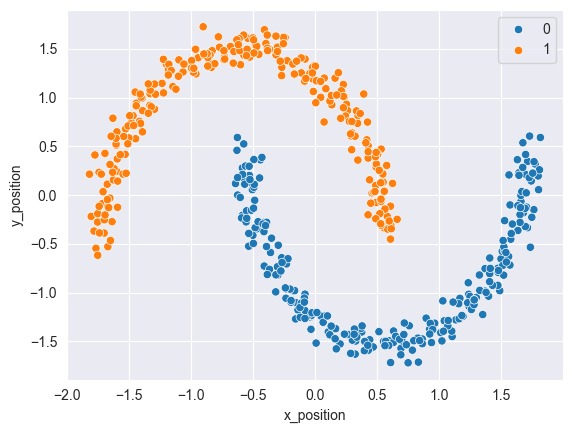

In [39]:
sns.scatterplot(data=X_scaled, x="x_position", y="y_position", hue=hdbscan.labels_)
plt.show()

In [40]:
min_cluster_size = [3, 5, 7, 10]
min_samples = [None, 3, 5, 7]

In [41]:
results = []

for min_cluster in min_cluster_size:
    for min_sample in min_samples:
        hdb = HDBSCAN(min_cluster_size=min_cluster, min_samples=min_sample).fit(X_scaled)
        labels = hdb.labels_

        if len(set(labels)) <= 1:
            continue
        silhouette_scores = silhouette_score(X_scaled, labels)
        results.append(
            {
                "min_cluster_size": min_cluster,
                "min_samples": min_sample,
                "silhouette_score": silhouette_scores,
                "n_clusters": len(set(labels)) - (1 if -1 in labels else 0),
            }
        )
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="silhouette_score", ascending=False)

In [42]:
results_df

,min_cluster_size,min_samples,silhouette_score,n_clusters
3,3,7.0,0.389338,2
2,3,5.0,0.389338,2
5,5,3.0,0.389338,2
4,5,NaN,0.389338,2
6,5,5.0,0.389338,2
7,5,7.0,0.389338,2
9,7,3.0,0.389338,2
8,7,NaN,0.389338,2
12,10,NaN,0.389338,2
13,10,3.0,0.389338,2
